In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from sklearn.preprocessing import StandardScaler
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm
from imblearn.over_sampling import SMOTE

# Classification models used
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA

import warnings
warnings.filterwarnings('ignore')
!pip install shap
import shap

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
taiwanese_bankruptcy_prediction = fetch_ucirepo(id=572)
X = taiwanese_bankruptcy_prediction.data.features
y = taiwanese_bankruptcy_prediction.data.targets

y.value_counts()
# Size of minority class (bankrupt)
220/len(y)

0.03226279513125092

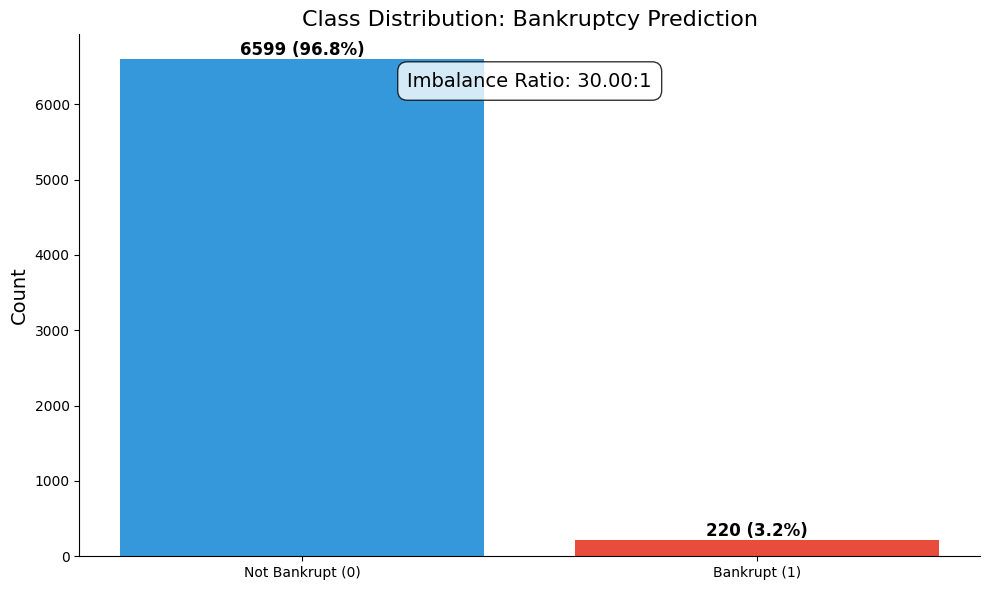

In [ ]:
def plot_class_distribution(y, figsize=(10, 6)):
    y_array = np.array(y).astype(int).ravel()

    class_counts = np.bincount(y_array)
    n_not_bankrupt = class_counts[0]
    n_bankrupt = class_counts[1] if len(class_counts) > 1 else 0


    total = len(y_array)
    pct_not_bankrupt = (n_not_bankrupt / total) * 100
    pct_bankrupt = (n_bankrupt / total) * 100

    df = pd.DataFrame({
        'Class': ['Not Bankrupt (0)', 'Bankrupt (1)'],
        'Count': [n_not_bankrupt, n_bankrupt],
        'Percentage': [pct_not_bankrupt, pct_bankrupt]
    })

    fig, ax = plt.subplots(figsize=figsize)

    colors = ["#3498db", "#e74c3c"]
    bars = ax.bar(df['Class'], df['Count'], color=colors)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{df["Count"][i]} ({df["Percentage"][i]:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    imbalance_ratio = n_not_bankrupt / n_bankrupt if n_bankrupt > 0 else float('inf')
    ax.text(0.5, 0.9, f'Imbalance Ratio: {imbalance_ratio:.2f}:1',
            transform=ax.transAxes, ha='center', fontsize=14,
            bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8))

    ax.set_title('Class Distribution: Bankruptcy Prediction', fontsize=16)
    ax.set_ylabel('Count', fontsize=14)

    sns.despine()
    plt.tight_layout()

    return fig, ax

fig, ax = plot_class_distribution(y)
plt.show()

In [ ]:

def plot_normalized_histograms(X, y, figsize=(16, 8*48)):
    n_features = X.shape[1]
    n_rows = int(np.ceil(n_features / 2))


    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    if n_rows == 1:
        axes = np.array([axes])
    axes = axes.reshape(n_rows, 2)
    y_array = np.array(y)

    class0_mask = (y_array == 0)
    class1_mask = (y_array == 1)

    n_class0 = np.sum(class0_mask)
    n_class1 = np.sum(class1_mask)

    colors = ["#3498db", "#e74c3c"]

    # Plot each feature
    for i in range(n_features):
        row_idx = i // 2
        col_idx = i % 2

        ax = axes[row_idx, col_idx]
        feature_name = X.columns[i] if hasattr(X, 'columns') else f"Feature {i}"

        class0_data = X.iloc[class0_mask, i]
        class1_data = X.iloc[class1_mask, i]

        mean0 = class0_data.mean()
        mean1 = class1_data.mean()

        all_data = np.concatenate([class0_data, class1_data])
        min_val, max_val = np.min(all_data), np.max(all_data)
        bin_edges = np.linspace(min_val, max_val, 30)

        ax.hist(class0_data, bins=bin_edges, density=True, alpha=0.7,
                label=f'Not Bankrupt (n={n_class0})', color=colors[0])
        ax.hist(class1_data, bins=bin_edges, density=True, alpha=0.7,
                label=f'Bankrupt (n={n_class1})', color=colors[1])


        ax.axvline(mean0, color=colors[0], linestyle='--', linewidth=2,
                   label=f'Mean Not Bankrupt: {mean0:.2f}')
        ax.axvline(mean1, color=colors[1], linestyle='--', linewidth=2,
                   label=f'Mean Bankrupt: {mean1:.2f}')

        ax.set_title(f'{feature_name}', fontsize=14)
        ax.legend(fontsize='medium')
        sns.despine(ax=ax)

    if n_features % 2 != 0:
        axes[n_rows-1, 1].set_visible(False)


    plt.suptitle('Normalized Feature Distributions by Class', fontsize=20, y=0.998)
    plt.tight_layout(rect=[0, 0, 1, 0.99])

    return fig, axes

fig, axes = plot_normalized_histograms(X, y)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list

def plot_clustered_heatmap(data):
    """
    Plots a clustered heatmap of the correlation matrix of the input data.

    Args:
    data (pd.DataFrame): The input data to plot.

    Returns:
    None
    """

    # Compute correlation matrix
    corr_matrix = data.corr(numeric_only=True)

    # Replace infinite values with NaN
    corr_matrix = corr_matrix.replace([np.inf, -np.inf], np.nan)

    # Drop rows/columns with all NaNs (if any)
    corr_matrix = corr_matrix.dropna(axis=1, how='all').dropna(axis=0, how='all')

    # Compute linkage and reorder rows/cols
    link = linkage(corr_matrix, method='ward')
    idx = leaves_list(link)

    # Reorder the original corr_matrix (important!)
    corr_reordered = corr_matrix.iloc[idx, :].iloc[:, idx]

    # Plot clustered heatmap (no annotation for clarity)
    plt.figure(figsize=(8, 6))  # Adjusted figure size
    sns.heatmap(corr_reordered, cmap='vlag', center=0,
                cbar_kws={'label': 'Correlation'},
                xticklabels=False, yticklabels=False)
    plt.title("Clustered Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()


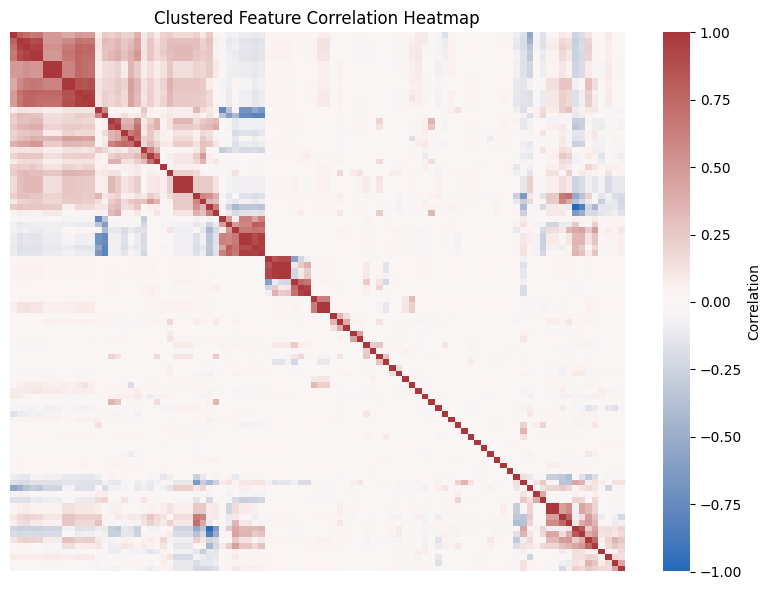

In [ ]:
plot_clustered_heatmap(X)

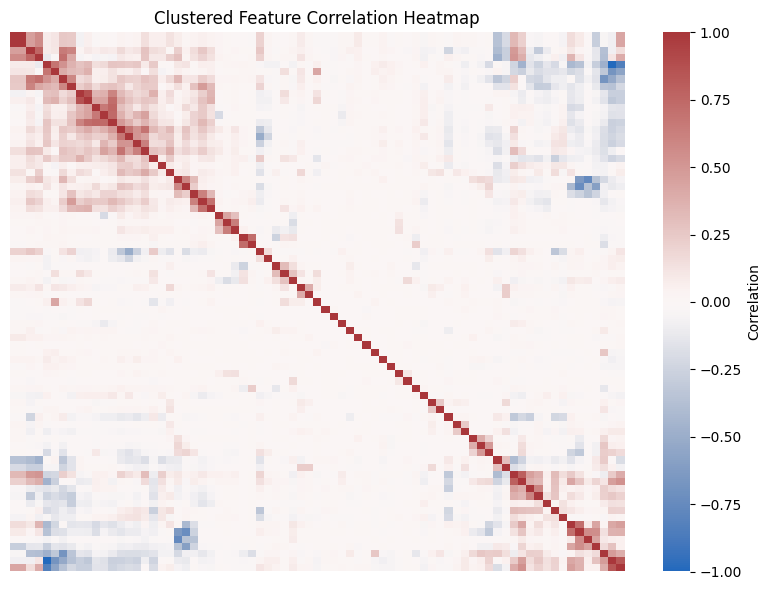

In [ ]:
plot_clustered_heatmap(X)

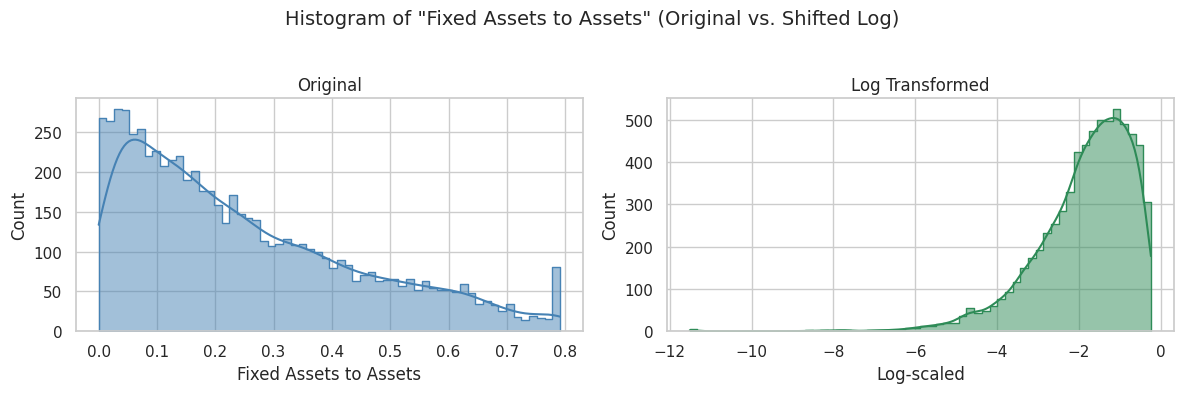

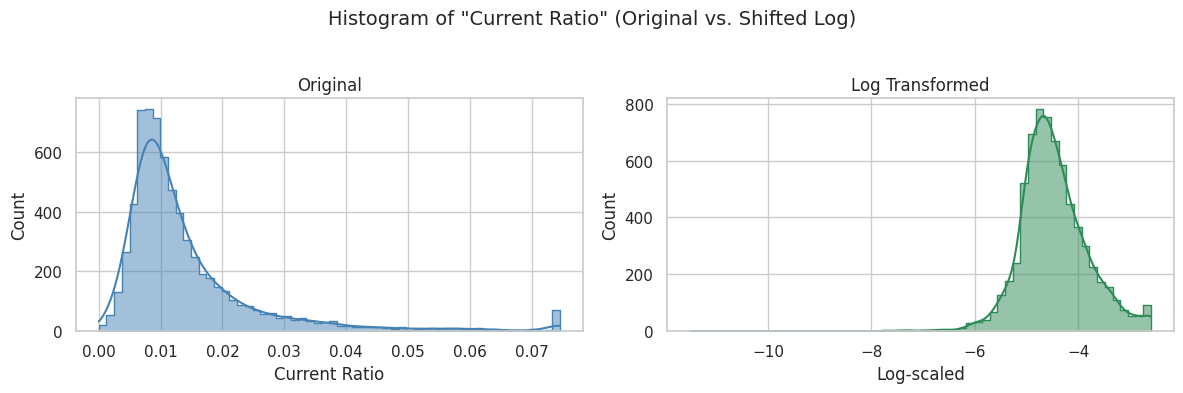

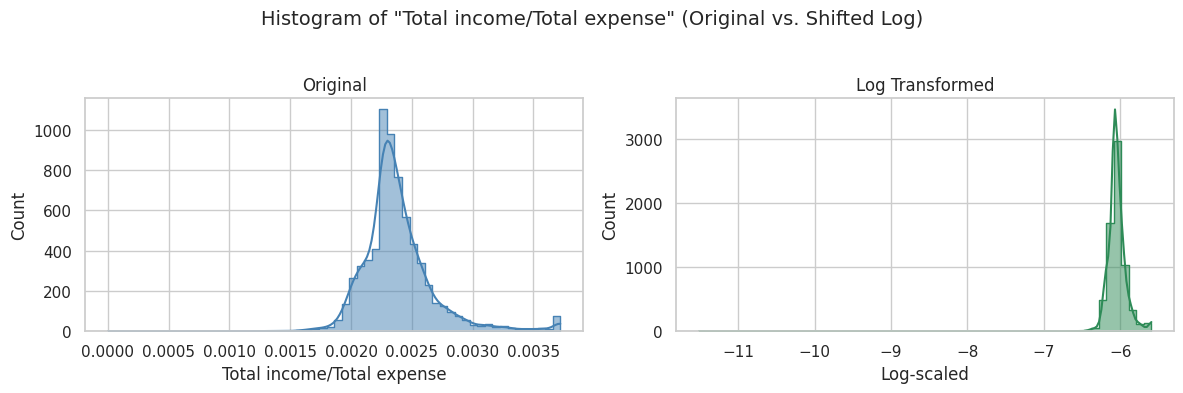

In [ ]:
columns_to_plot = [' Fixed Assets to Assets', ' Current Ratio', ' Total income/Total expense']

# Set style
sns.set(style="whitegrid")

for col in columns_to_plot:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Histogram of "{col.strip()}" (Original vs. Shifted Log)', fontsize=14)

    col_values = X_copy[col].clip(upper=X_copy[col].quantile(0.99))  # limit outliers

    # Original histogram
    sns.histplot(col_values, bins=60, kde=True, ax=axs[0], color='steelblue', element='step')
    axs[0].set_title('Original')
    axs[0].set_xlabel(col.strip())

    # Shift values if min <= 0
    min_val = col_values.min()
    if min_val <= 0:
        shifted = col_values - min_val + 1e-5
        transformed = np.log(shifted)
    else:
        transformed = np.log1p(col_values)

    # Transformed histogram
    sns.histplot(transformed, bins=60, kde=True, ax=axs[1], color='seagreen', element='step')
    axs[1].set_title('Log Transformed')
    axs[1].set_xlabel('Log-scaled')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
skew_thresh = 1

numeric_cols = X.select_dtypes(include=[np.number])
skewness = numeric_cols.skew().sort_values(ascending=False)
skewed_cols = skewness[skewness > skew_thresh].index.tolist()

print(f"Applying log1p to {len(skewed_cols)} skewed features: {skewed_cols}")
X[skewed_cols] = X[skewed_cols].apply(np.log1p)

Applying log1p to 61 skewed features: [' Fixed Assets to Assets', ' Current Ratio', ' Total income/Total expense', ' Net Value Growth Rate', ' Contingent liabilities/Net worth', ' Realized Sales Gross Profit Growth Rate', ' Continuous Net Profit Growth Rate', ' Total Asset Return Growth Rate Ratio', ' Revenue per person', ' Quick Assets/Current Liability', ' Total debt/Total net worth', ' Degree of Financial Leverage (DFL)', ' Inventory/Working Capital', ' Revenue Per Share (Yuan ¥)', ' Non-industry income and expenditure/revenue', ' Equity to Long-term Liability', ' Quick Ratio', ' Average Collection Days', ' Liability-Assets Flag', ' Allocation rate per person', ' Liability to Equity', ' Accounts Receivable Turnover', ' Long-term fund suitability ratio (A)', ' Current Liability to Equity', ' Current Liabilities/Equity', ' Total assets to GNP price', ' Borrowing dependency', ' Cash Flow to Equity', ' Cash/Current Liability', ' Current Liability to Current Assets', ' Inventory and acco

In [ ]:
# Dropped features with p>0.90 and split
columns_to_drop = [65,88,17,4,15,41,26,9,7,0,90,22,1,85,18,42,39,72,5,85]

column_names_to_drop = X.columns[columns_to_drop]

X.drop(columns=column_names_to_drop, axis=1, inplace=True)

scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=162)
X_train.head()

,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Pre-tax net Interest Rate,Non-industry income and expenditure/revenue,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (A),...,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Total assets to GNP price,No-credit Interval,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
4184,-1.078264,-0.563795,0.009532,-0.017720,1.464551,0.949403,0.061832,-0.182213,-0.890455,-0.675021,...,0.028583,-0.036089,-0.034272,-0.057462,-0.012429,-0.247503,-0.065701,-0.068574,0.0,-0.523264
4233,0.946170,0.434702,0.036172,-0.001488,-0.708161,-1.198089,1.094588,-0.182331,-0.207114,-0.061575,...,0.034067,-0.872801,-0.034272,-0.059582,0.054191,0.182859,-0.054965,-0.015101,0.0,0.879828
2322,0.120403,-0.006237,0.020648,-0.019136,-0.708165,-1.198099,-0.715428,-0.182229,-0.165519,-0.652121,...,0.048442,0.288747,-0.034272,-0.059744,-0.108517,0.072560,-0.043208,0.030166,0.0,-0.688314
1267,-0.023020,-0.541663,0.019282,0.002588,1.461565,-1.198099,0.042198,-0.182123,0.456221,-0.386424,...,-0.070123,0.116193,-0.034272,-0.059952,-0.008325,0.057998,-0.024094,0.084540,0.0,-0.380538
4566,-0.302912,0.379798,0.015165,-0.006956,-0.708144,-1.198087,-0.188791,-0.182213,-0.890455,-0.536485,...,0.159622,1.412913,-0.034272,-0.060059,-0.040519,-0.020542,0.635541,0.323601,0.0,-0.490849


In [ ]:
from imblearn.combine import SMOTETomek

def print_class_proportions(y, label=""):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    proportions = {cls: round(cnt / total, 3) for cls, cnt in zip(unique, counts)}
    print(f"{label} class proportions:", proportions)

# Before resampling
print_class_proportions(y_train, label="Before")

# Apply SMOTE-Tomek
smt = SMOTETomek(sampling_strategy=0.3, random_state=42)
X_train, y_train = smt.fit_resample(X_train, y_train)

# After resampling
print_class_proportions(y_train, label="After")

Before class proportions: {np.int64(0): np.float64(0.968), np.int64(1): np.float64(0.032)}
After class proportions: {np.int64(0): np.float64(0.77), np.int64(1): np.float64(0.23)}


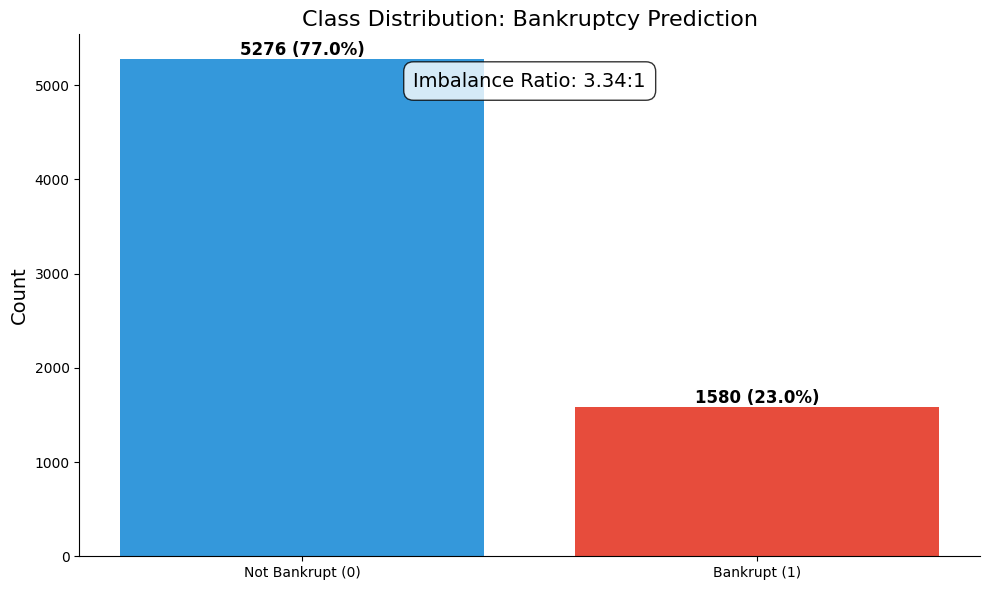

In [ ]:
fig, ax = plot_class_distribution(y_train)
plt.show()

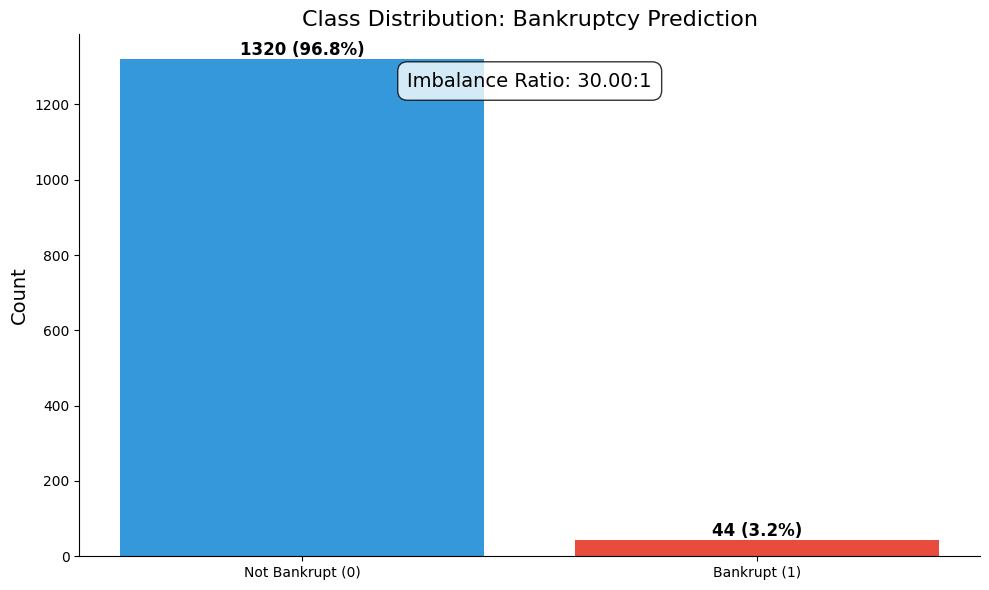

In [ ]:
fig, ax = plot_class_distribution(y_test)
plt.show()

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(random_state=162)
rf.fit(X_train, y_train)
selector = SelectFromModel(rf, prefit=True, threshold='median')
X_train_rf = selector.transform(X_train)
X_test_rf = selector.transform(X_test)
print(X_train_rf.shape)
print(X_test_rf.shape)


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss',random_state=162)
xgb.fit(X_train, y_train)

selector = SelectFromModel(xgb, prefit=True, threshold='median')
X_train_xgb = selector.transform(X_train)
X_test_xgb = selector.transform(X_test)
print(X_train_xgb.shape)
print(X_test_xgb.shape)

gb = GradientBoostingClassifier(random_state=162)
gb.fit(X_train, y_train)

selector = SelectFromModel(gb, prefit=True, threshold='median')
X_train_gb = selector.transform(X_train)
X_test_gb = selector.transform(X_test)
print(X_train_gb.shape)
print(X_test_gb.shape)

(6856, 38)
(1364, 38)
(6856, 38)
(1364, 38)
(6856, 38)
(1364, 38)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_train_sel, X_test_sel, y_train, y_test):
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1] if hasattr(model, "predict_proba") else y_pred

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

results = []

# Grad Boost
grad_model = GradientBoostingClassifier(random_state=162)
results.append(evaluate_model("Grad Boosting", grad_model, X_train_gb, X_test_gb, y_train, y_test))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100,random_state=162)
results.append(evaluate_model("Random Forest", rf_model, X_train_rf, X_test_rf, y_train, y_test))

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=162)
results.append(evaluate_model("XGBoost", xgb_model, X_train_xgb, X_test_xgb, y_train, y_test))

# Create DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.round(3)
print(results_df)

           Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Grad Boosting     0.959      0.403   0.568     0.472    0.947
1  Random Forest     0.963      0.440   0.500     0.468    0.950
2        XGBoost     0.973      0.578   0.591     0.584    0.957


In [ ]:
def precision_at_k_plot(y_true, y_scores, k_list):
    results = []


    df = pd.DataFrame({'true': y_true, 'score': y_scores})
    df_sorted = df.sort_values(by='score', ascending=False).reset_index(drop=True)

    for k in k_list:
        top_k = df_sorted.iloc[:k]
        precision = top_k['true'].sum() / k
        results.append({'k': k, 'Precision@K': precision})

    results_df = pd.DataFrame(results)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=results_df, x='k', y='Precision@K', palette='Blues_d', ax=ax) # Pass ax to barplot
    plt.title('Precision@K for Bankruptcy Prediction', fontsize=14)
    plt.xlabel('Top K Predictions for Bankruptcy')
    plt.ylabel('Precision@K')
    plt.ylim(0, 1)
    for i, row in results_df.iterrows():
        plt.text(i, row['Precision@K'] + 0.02, f"{row['Precision@K']:.2f}",
                 ha='center', va='bottom', fontsize=14)
    plt.tight_layout()

    ax.set_axisbelow(True)
    plt.grid(True, axis='y')
    plt.show()

    return results_df

k_values = [5, 10, 20, 44]
y_test = y_test['Bankrupt?'].values.ravel()

Best Threshold: 0.45999999999999985
Best F1 Score at Threshold: 0.49019607843137253


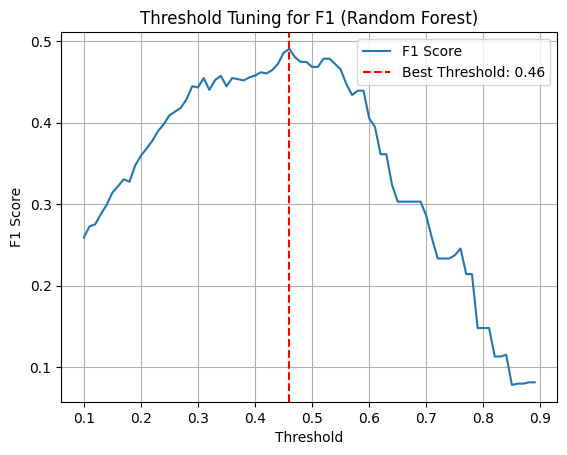

Classification Report at Tuned Threshold:

              precision    recall  f1-score   support

           0      0.985     0.975     0.980      1320
           1      0.431     0.568     0.490        44

    accuracy                          0.962      1364
   macro avg      0.708     0.772     0.735      1364
weighted avg      0.968     0.962     0.964      1364

ROC AUC Score (Random Forest): 0.9497847796143251


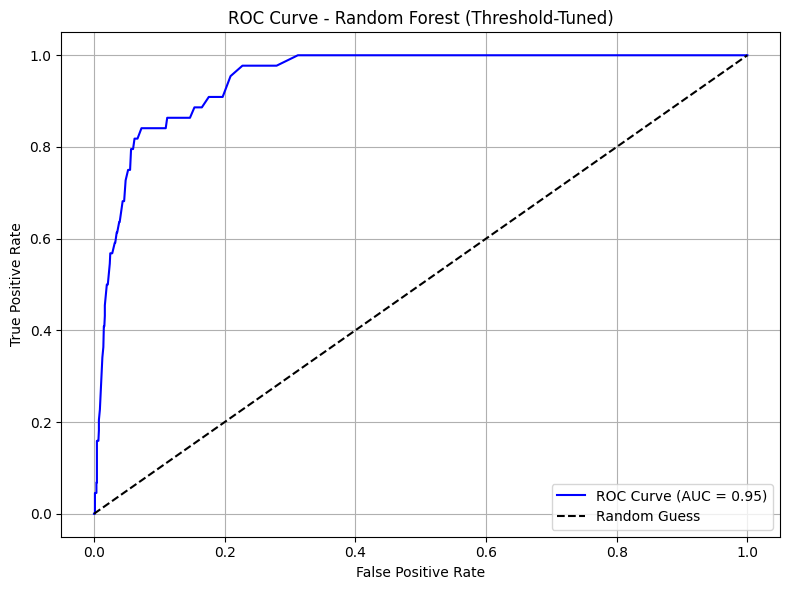

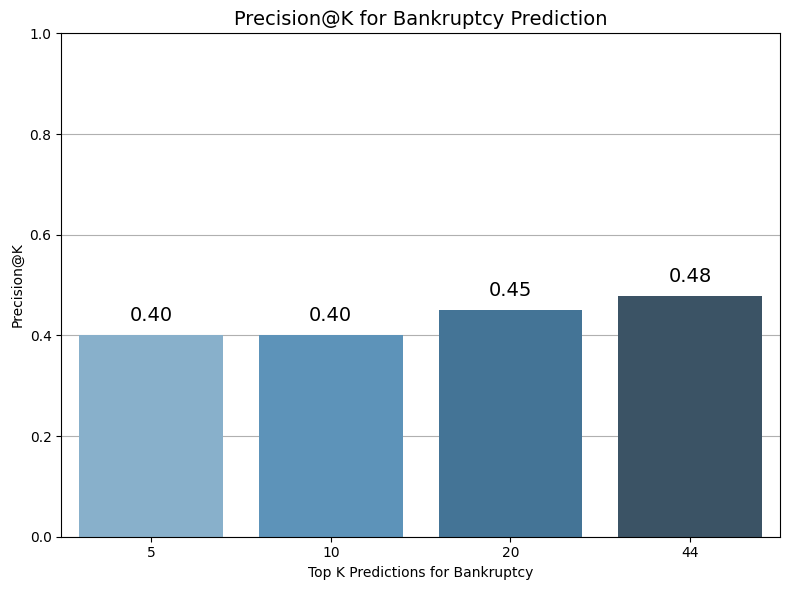

,k,Precision@K
0,5,0.400000
1,10,0.400000
2,20,0.450000
3,44,0.477273


In [ ]:
y_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_rf >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best Threshold:", best_thresh)
print("Best F1 Score at Threshold:", best_f1)


plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Threshold: {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning for F1 (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

y_pred_final_rf = (y_proba_rf >= best_thresh).astype(int)

from sklearn.metrics import classification_report
print("Classification Report at Tuned Threshold:\n")
print(classification_report(y_test, y_pred_final_rf,digits=3))

from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print("ROC AUC Score (Random Forest):", roc_auc_rf)

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Threshold-Tuned)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

precision_at_k_plot(y_test, y_proba_rf, k_values)

In [ ]:
print("y_proba_rf shape:", y_proba_rf.shape)
print("y_test shape:", y_test.shape)
print("k_values:", k_values)


y_proba_rf shape: (1364,)
y_test shape: (1364,)
k_values: [5, 10, 20, 44]


Best Threshold: 0.4199999999999998
Best F1 Score at Threshold: 0.5210084033613446


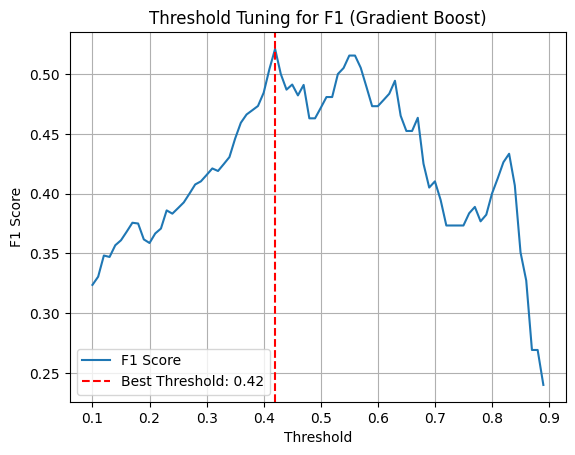

Classification Report at Tuned Threshold:

              precision    recall  f1-score   support

           0      0.990     0.967     0.978      1320
           1      0.413     0.705     0.521        44

    accuracy                          0.958      1364
   macro avg      0.702     0.836     0.750      1364
weighted avg      0.971     0.958     0.963      1364

ROC AUC Score (Grad Boost): 0.9474173553719007


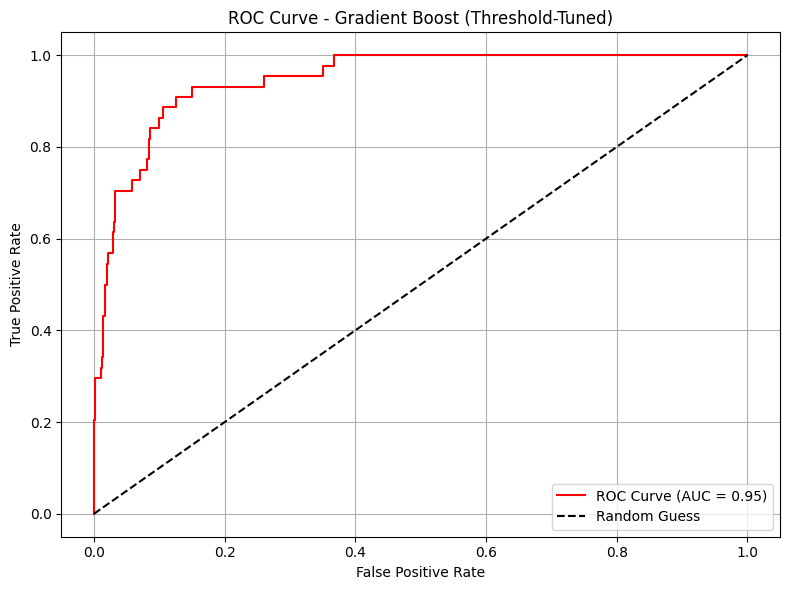

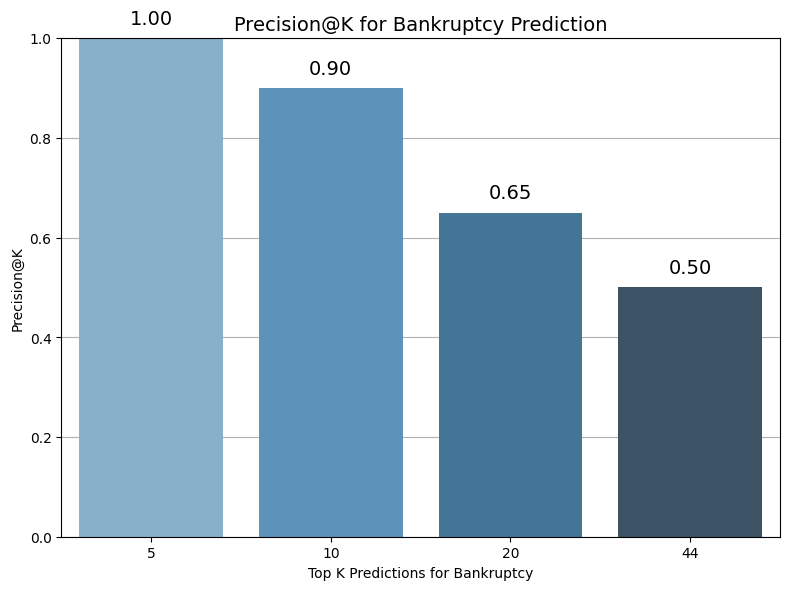

,k,Precision@K
0,5,1.00
1,10,0.90
2,20,0.65
3,44,0.50


In [ ]:
y_proba_grad = grad_model.predict_proba(X_test_gb)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_grad >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best Threshold:", best_thresh)
print("Best F1 Score at Threshold:", best_f1)


plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Threshold: {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning for F1 (Gradient Boost)')
plt.legend()
plt.grid(True)
plt.show()

y_pred_final_grad = (y_proba_grad >= best_thresh).astype(int)


print("Classification Report at Tuned Threshold:\n")
print(classification_report(y_test, y_pred_final_grad,digits=3))


roc_auc_grad = roc_auc_score(y_test, y_proba_grad)
print("ROC AUC Score (Grad Boost):", roc_auc_grad)

fpr, tpr, _ = roc_curve(y_test, y_proba_grad)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_grad:.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boost (Threshold-Tuned)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

precision_at_k_plot(y_test, y_proba_grad, k_values)

Best Threshold: 0.3599999999999999
Best F1 Score at Threshold: 0.6041666666666666


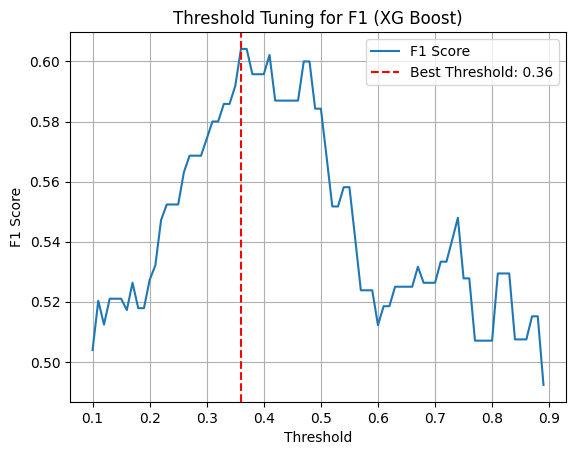

Classification Report at Tuned Threshold:

              precision    recall  f1-score   support

           0      0.989     0.983     0.986      1320
           1      0.558     0.659     0.604        44

    accuracy                          0.972      1364
   macro avg      0.773     0.821     0.795      1364
weighted avg      0.975     0.972     0.973      1364

ROC AUC Score (XG Boost): 0.9570936639118457


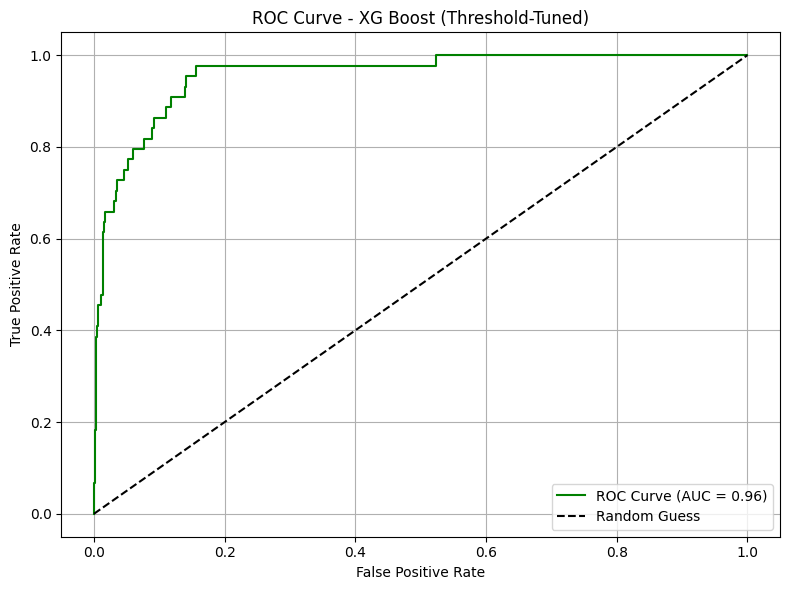

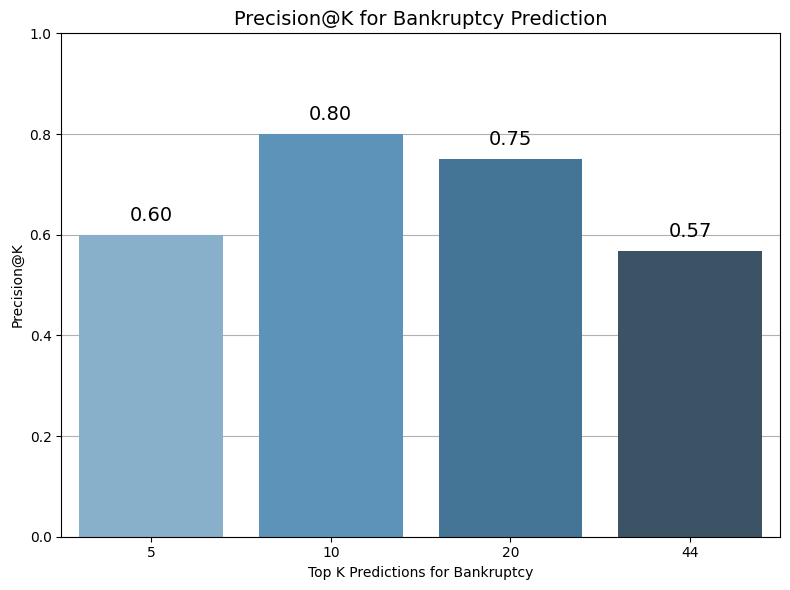

,k,Precision@K
0,5,0.600000
1,10,0.800000
2,20,0.750000
3,44,0.568182


In [ ]:
y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_xgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best Threshold:", best_thresh)
print("Best F1 Score at Threshold:", best_f1)


plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Threshold: {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning for F1 (XG Boost)')
plt.legend()
plt.grid(True)
plt.show()

y_pred_final_xgb = (y_proba_xgb >= best_thresh).astype(int)


print("Classification Report at Tuned Threshold:\n")
print(classification_report(y_test, y_pred_final_xgb,digits=3))


roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("ROC AUC Score (XG Boost):", roc_auc_xgb)

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_xgb:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XG Boost (Threshold-Tuned)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

precision_at_k_plot(y_test, y_proba_xgb, k_values)

Best F1: 0.5926 at Threshold: 0.60


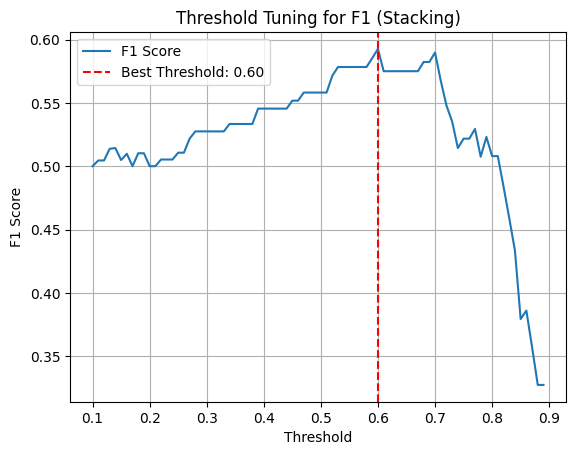

              precision    recall  f1-score   support

           0      0.985     0.990     0.988      1320
           1      0.649     0.545     0.593        44

    accuracy                          0.976      1364
   macro avg      0.817     0.768     0.790      1364
weighted avg      0.974     0.976     0.975      1364

ROC AUC: 0.9567493112947658


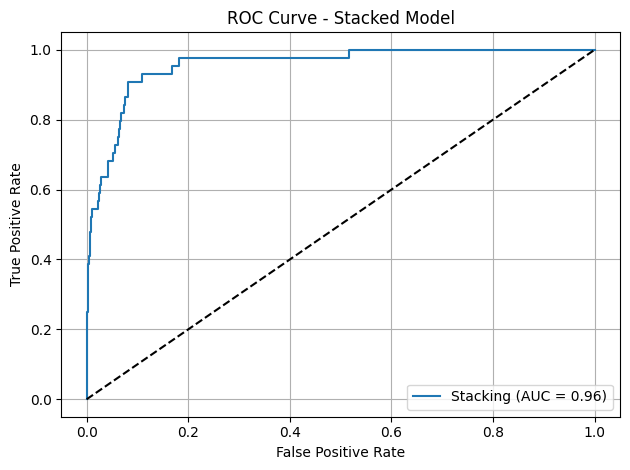

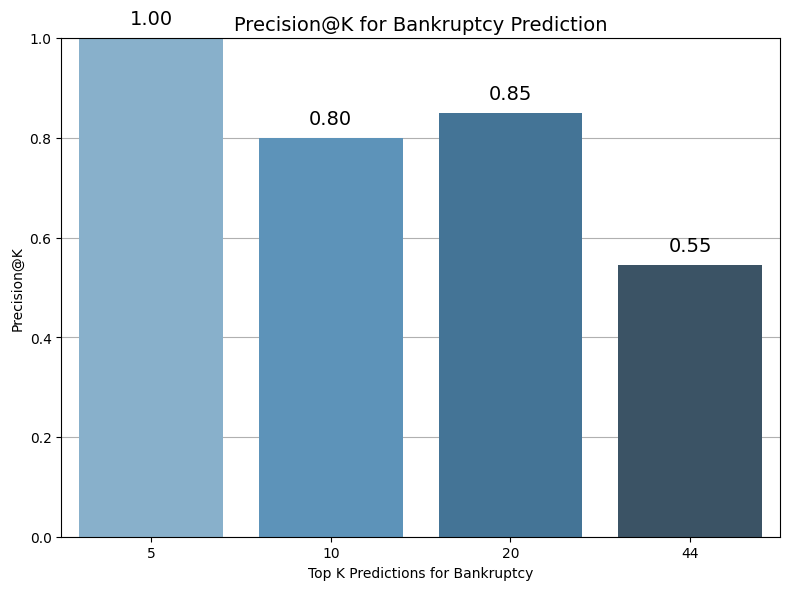

,k,Precision@K
0,5,1.000000
1,10,0.800000
2,20,0.850000
3,44,0.545455


In [ ]:
rf_features = X_train.columns[selector.get_support(indices=True)].tolist() # Get selected features from original DataFrame
xgb_features = X_train.columns[selector.get_support(indices=True)].tolist()
gb_features = X_train.columns[selector.get_support(indices=True)].tolist()

common_features = list(set(rf_features + xgb_features + gb_features))

X_train_stack = X_train[common_features]
X_test_stack = X_test[common_features]

rf_model.fit(X_train_stack, y_train)
xgb_model.fit(X_train_stack, y_train)
grad_model.fit(X_train_stack, y_train)

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('gb', grad_model)
    ],
    final_estimator= LogisticRegression(C=0.1, penalty='l2', max_iter=2000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train_stack, y_train)

y_probs = stack.predict_proba(X_test_stack)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best F1: {best_f1:.4f} at Threshold: {best_threshold:.2f}")
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning for F1 (Stacking)')
plt.legend()
plt.grid(True)
plt.show()

y_pred_thresh = (y_probs >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_thresh,digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_probs))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacking (AUC = {roc_auc_score(y_test, y_probs):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision_at_k_plot(y_test, y_probs, k_values)

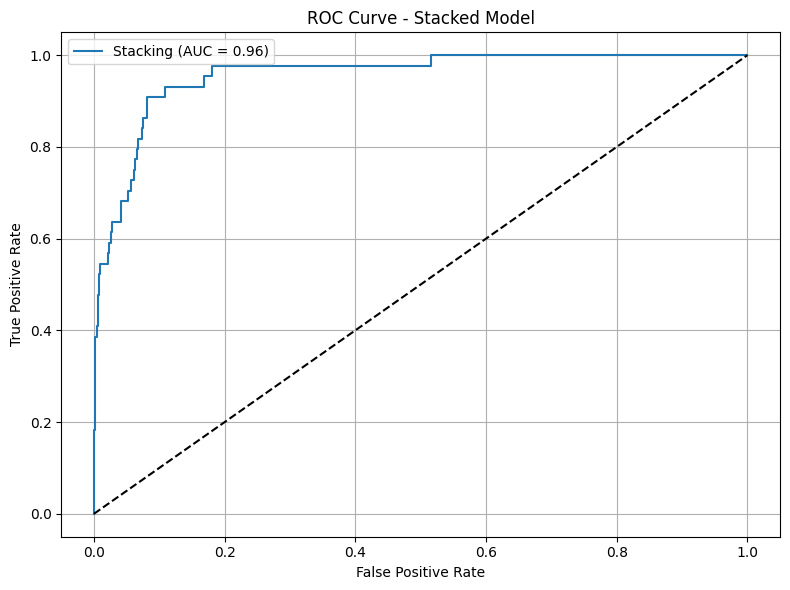

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacking (AUC = {roc_auc_score(y_test, y_probs):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

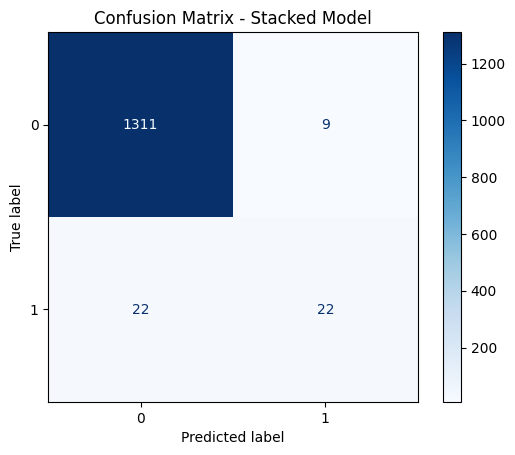

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh, cmap='Blues')
plt.title('Confusion Matrix - Stacked Model')
plt.show()

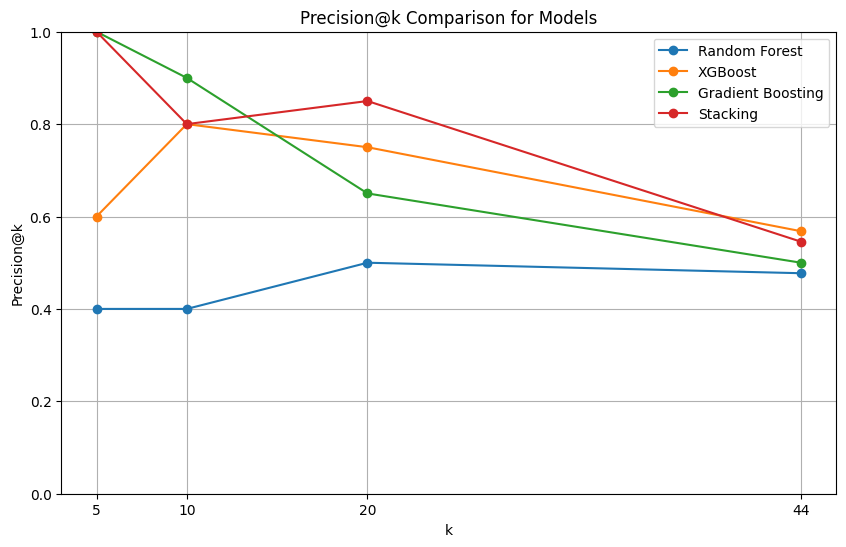

In [ ]:

def precision_at_k(y_true, y_scores, k):
    # Sort by score descending
    order = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[order]
    top_k = y_true_sorted[:k]
    return top_k.sum() / k

def precision_at_k_plot_all(y_true, y_score_dict, k_values):
    plt.figure(figsize=(10, 6))
    for model_name, y_scores in y_score_dict.items():
        precisions = [precision_at_k(y_true, y_scores, k) for k in k_values]
        plt.plot(k_values, precisions, marker='o', label=model_name)

    plt.xlabel('k')
    plt.ylabel('Precision@k')
    plt.title('Precision@k Comparison for Models')
    plt.xticks(k_values)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage:
y_test_1d = y_test.ravel()  # make sure y_test is 1D
y_score_dict = {
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'Gradient Boosting': y_proba_grad,
    'Stacking': y_probs
}

k_values = [5, 10, 20, 44]

precision_at_k_plot_all(y_test_1d, y_score_dict, k_values)


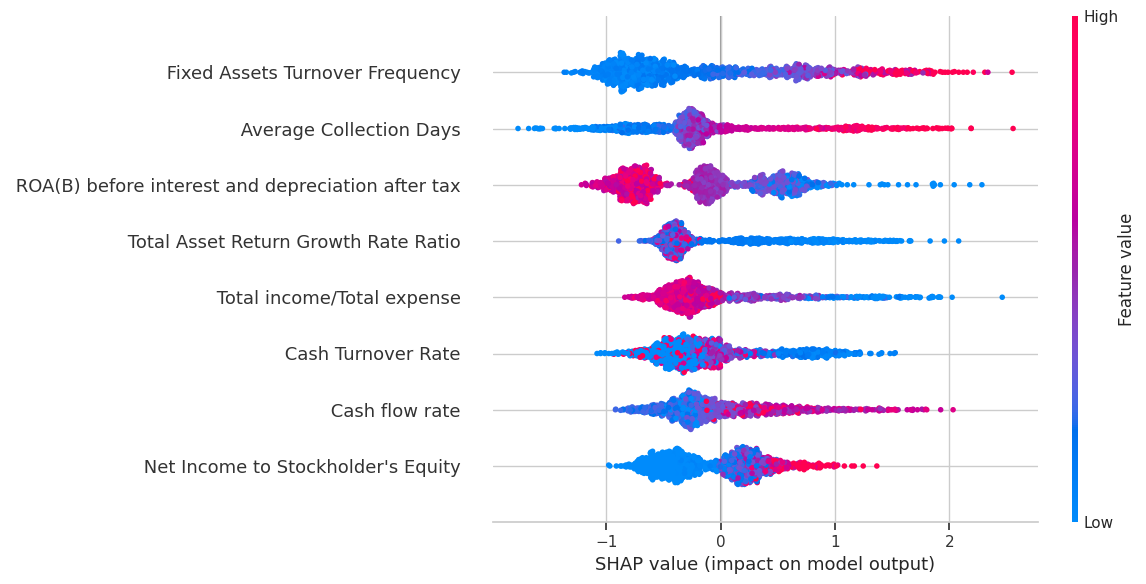

In [ ]:
model =  XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=162)
model.fit(X_train_xgb, y_train.values)

explainer = shap.Explainer(model, X_train_xgb)
shap_values = explainer(X_test_xgb)

feature_names = X_train.columns[selector.get_support()].tolist()

shap.summary_plot(shap_values, X_test_xgb, max_display=8, feature_names=feature_names, plot_size=(12, 6))

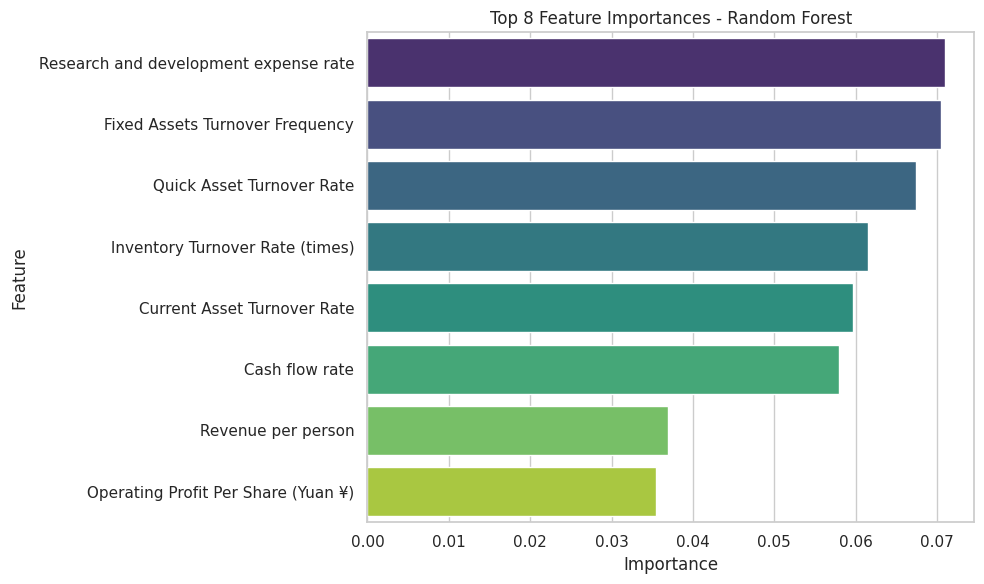

In [ ]:
rf_importances = rf_model.feature_importances_
rf_features = X_train.columns[selector.get_support()].tolist()
# Create a DataFrame and get top 8
rf_df = pd.DataFrame({'Feature': rf_features, 'Importance': rf_importances})
rf_df = rf_df.sort_values(by='Importance', ascending=False).head(8)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 8 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

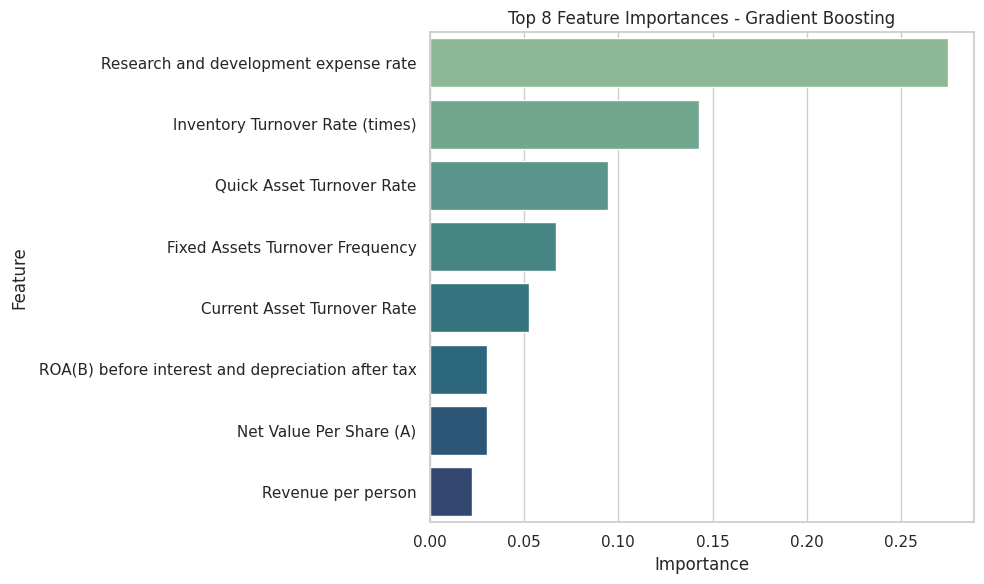

In [ ]:
gb_importances = grad_model.feature_importances_
gb_features = X_train.columns[selector.get_support()].tolist()

gb_df = pd.DataFrame({'Feature': gb_features, 'Importance': gb_importances})
gb_df = gb_df.sort_values(by='Importance', ascending=False).head(8)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=gb_df, x='Importance', y='Feature', palette='crest')
plt.title('Top 8 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

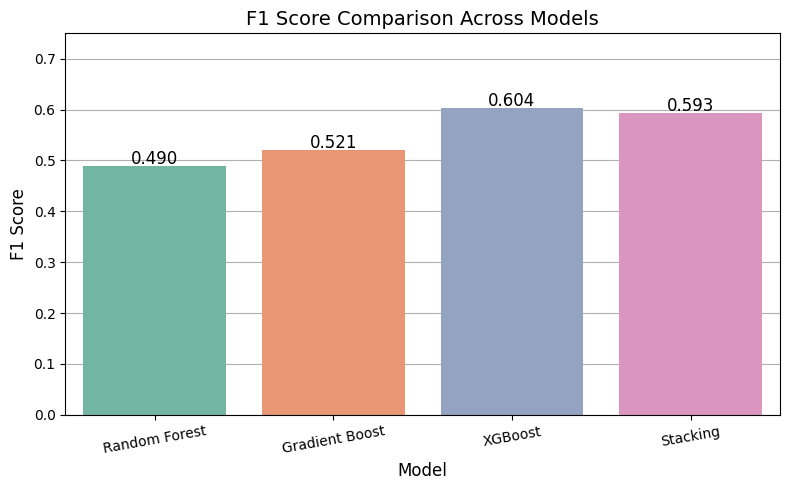

In [ ]:
f1_scores = {
    'Random Forest': 0.49,
    'Gradient Boost': 0.521,
    'XGBoost': 0.604,
    'Stacking': 0.593
}

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette='Set2')

# Add score labels above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('F1 Score Comparison Across Models', fontsize=14)
plt.ylim(0, 0.75)
plt.xticks(rotation=10)
plt.tight_layout()
ax.set_axisbelow(True)
plt.grid(True, axis='y')

plt.show()